In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Loaded the dataset using the csv files of nodes and edges seperately
nodes_df = pd.read_csv("/content/nodes.csv")
edges_df = pd.read_csv("/content/edges.csv")

print("Nodes Data:")
print(nodes_df.head())
print("\nEdges Data:")
print(edges_df.head())

# Created graph G using the edge dataset
G = nx.from_pandas_edgelist(edges_df, source='source', target='target')

#checking the number of odes and edges in gmal and csv files respectively
print("Nodes in GML:", G.number_of_nodes())
print("Nodes in CSV:", len(nodes_df) )

print("Edges in GML:", G.number_of_edges())
print("Edges in CSV:", len(edges_df))

#number of nodes and edges used in G
print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

for _, row in nodes_df.iterrows():
    node_id = row['id']
    if node_id in G.nodes:
        G.nodes[node_id].update(row.to_dict())

print("Final Graph:")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# View a few nodes with attributes
list(G.nodes(data=True))[:5]


Nodes Data:
   id  s  name gendermf branch2lettersegaime           state  \
0   1  1     0        m                   cs       telangana   
1   2  2     0        m                   cs  andhra pradesh   
2   3  3     0        m                   cs       telengana   
3   4  4     0        m                   cs       telangana   
4   5  5     0        f                   cs  andhra pradesh   

   averagehoursofsleeppernight  howmanylanguagesdoyouknow  gaminghoursperweek  
0                          5.0                        3.0                 7.0  
1                          6.0                        5.0                 3.0  
2                          8.0                        6.0                10.0  
3                          8.0                        NaN                 NaN  
4                          7.0                        5.0                 1.0  

Edges Data:
   source  target
0       1      90
1       1      46
2       1       8
3       1      25
4       1      49
No

[(1,
  {'id': 1,
   's': 1,
   'name': 0,
   'gendermf': 'm',
   'branch2lettersegaime': 'cs',
   'state': 'telangana',
   'averagehoursofsleeppernight': 5.0,
   'howmanylanguagesdoyouknow': 3.0,
   'gaminghoursperweek': 7.0}),
 (90,
  {'id': 90,
   's': 90,
   'name': 0,
   'gendermf': 'f',
   'branch2lettersegaime': 'ai',
   'state': 'telangana',
   'averagehoursofsleeppernight': 4.0,
   'howmanylanguagesdoyouknow': 3.0,
   'gaminghoursperweek': 0.0}),
 (46,
  {'id': 46,
   's': 46,
   'name': 0,
   'gendermf': 'm',
   'branch2lettersegaime': 'cs',
   'state': 'andhra pradesh',
   'averagehoursofsleeppernight': 6.0,
   'howmanylanguagesdoyouknow': 3.0,
   'gaminghoursperweek': 10.0}),
 (8,
  {'id': 8,
   's': 8,
   'name': 0,
   'gendermf': 'm',
   'branch2lettersegaime': 'cs',
   'state': 'telangana',
   'averagehoursofsleeppernight': 8.0,
   'howmanylanguagesdoyouknow': 3.0,
   'gaminghoursperweek': 0.0}),
 (25,
  {'id': 25,
   's': 25,
   'name': 0,
   'gendermf': 'm',
   'branch2

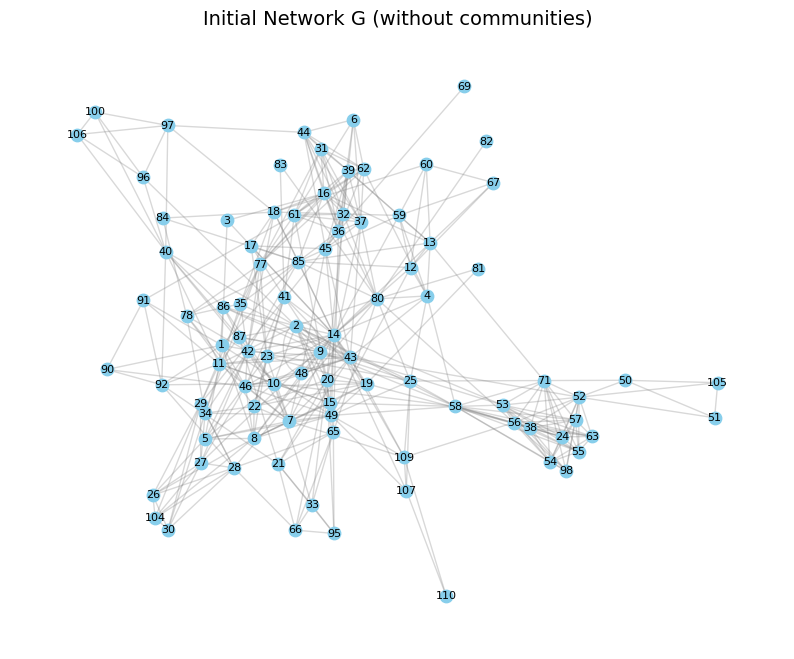

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)  # For consistent layout
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=80)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='black') # You can remove this line if node labels are too cluttered
plt.title("Initial Network G (without communities)", fontsize=14)
plt.axis("off")
plt.show()

Average degree: 8.945054945054945
Density: 0.09938949938949938
Is connected: True


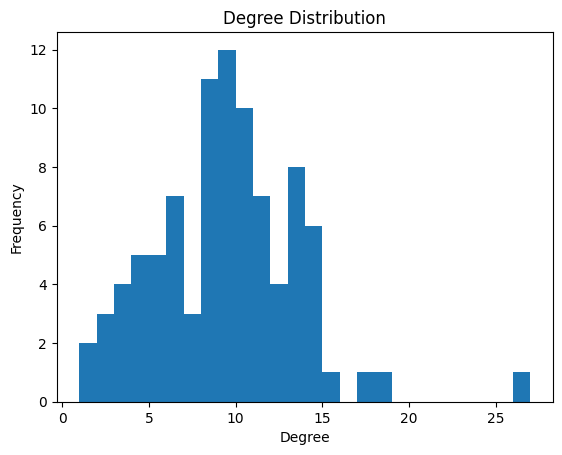

In [ ]:
# Graph metrics
print("Average degree:", sum(dict(G.degree()).values()) / G.number_of_nodes())
print("Density:", nx.density(G))
print("Is connected:", nx.is_connected(G))

# Degree distribution
degrees = [d for n, d in G.degree()]
plt.hist(degrees, bins=range(1, max(degrees)+1))
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#computing centrality measures
deg_cent = nx.degree_centrality(G)
bet_cent = nx.betweenness_centrality(G)
clos_cent = nx.closeness_centrality(G)

# Top 5 most central students
top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:5]
top_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:5]
top_clos = sorted(clos_cent.items(), key=lambda x: x[1], reverse=True)[:5]

print(" Top 5 by Degree Centrality:\n", top_deg)
print("\n")
print(" Top 5 by Betweenness Centrality:\n", top_bet)
print("\n")
print(" Top 5 by Closeness Centrality:", top_clos)
print("\n")

 Top 5 by Degree Centrality:
 [(14, 0.3), (43, 0.2), (58, 0.18888888888888888), (2, 0.16666666666666669), (49, 0.15555555555555556)]


 Top 5 by Betweenness Centrality:
 [(14, 0.1626374830221174), (43, 0.11700935237181155), (80, 0.09785598879345281), (2, 0.06996137078936758), (58, 0.06191089443339184)]


 Top 5 by Closeness Centrality: [(14, 0.5487804878048781), (43, 0.5113636363636364), (80, 0.5027932960893855), (2, 0.4891304347826087), (49, 0.45454545454545453)]




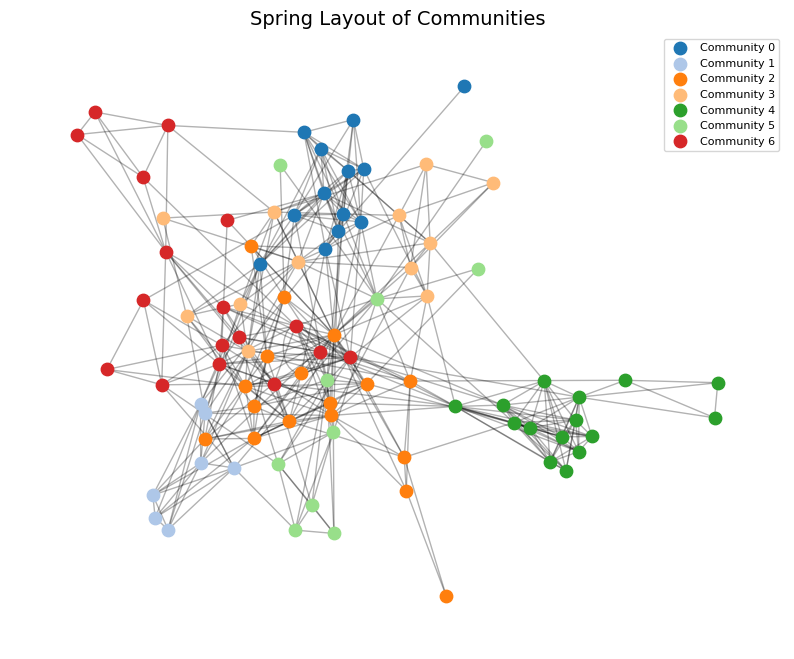

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import community.community_louvain as community_louvain

# Detect communities
partition = community_louvain.best_partition(G)
nx.set_node_attributes(G, partition, "community")

# Spring layout
pos = nx.spring_layout(G, seed=42)

# Unique communities
communities = set(partition.values())

num_comms = len(set(partition.values())) # later will be used in finding k in kmeans

# allot a color for each community
colors = plt.cm.tab20(range(len(communities)))  # nice, distinct colors

# Draw each community separately
plt.figure(figsize=(10, 8))
for comm, color in zip(communities, colors):
    nodes_in_comm = [node for node, c in partition.items() if c == comm]
    nx.draw_networkx_nodes(G, pos,
                           nodelist=nodes_in_comm,
                           node_color=[color],
                           node_size=80,
                           label=f"Community {comm}")

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.3)

# Turn off labels and axis for clean plot
plt.axis("off")
plt.legend(scatterpoints=1, fontsize=8)
plt.title("Spring Layout of Communities", fontsize=14)
plt.show()

In [ ]:

if "gendermf" in nodes_df.columns:
    assort = nx.attribute_assortativity_coefficient(G, "gendermf")
    print("Gender Assortativity:", round(assort, 3))

Gender Assortativity: 0.526


In [ ]:
if "branch2lettersegaime" in nodes_df.columns:
    assort = nx.attribute_assortativity_coefficient(G, "branch2lettersegaime")
    print("branch Assortativity:", round(assort, 3))



branch Assortativity: 0.118


In [ ]:

if "state" in nodes_df.columns:
    assort = nx.attribute_assortativity_coefficient(G, "state")
    print("state Assortativity:", round(assort, 3))

state Assortativity: 0.053


In [ ]:
if "averagehoursofsleeppernight" in nodes_df.columns:
    assort = nx.attribute_assortativity_coefficient(G, "averagehoursofsleeppernight")
    print("average_sleep_hours Assortativity:", round(assort, 3))


average_sleep_hours Assortativity: -0.02


In [ ]:
if "howmanylanguagesdoyouknow" in nodes_df.columns:
    assort = nx.attribute_assortativity_coefficient(G, "howmanylanguagesdoyouknow")
    print("number_of_languages_you_know Assortativity:", round(assort, 3))


number_of_languages_you_know Assortativity: 0.019


In [ ]:


if "gaminghoursperweek" in nodes_df.columns:
    assort = nx.attribute_assortativity_coefficient(G, "gaminghoursperweek")
    print("gamings_hours_per_week Assortativity:", round(assort, 3))



gamings_hours_per_week Assortativity: 0.038


In [ ]:
from networkx.algorithms.link_prediction import (
    jaccard_coefficient,
    adamic_adar_index,
    preferential_attachment
)

for name, func in {
    "Jaccard": jaccard_coefficient,
    "Adamic-Adar": adamic_adar_index,
    "Preferential Attachment": preferential_attachment
}.items():
    preds = sorted(list(func(G)), key=lambda x: x[2], reverse=True)[:5]
    print(f"\n🔹 {name} top 5 predicted friendships:")
    for u, v, score in preds:
        print(f"{u} - {v}: {round(score, 3)}")



🔹 Jaccard top 5 predicted friendships:
63 - 71: 0.818
24 - 98: 0.8
55 - 98: 0.8
63 - 98: 0.7
6 - 31: 0.667

🔹 Adamic-Adar top 5 predicted friendships:
52 - 58: 4.238
16 - 39: 3.749
63 - 71: 3.617
32 - 62: 3.426
44 - 61: 3.426

🔹 Preferential Attachment top 5 predicted friendships:
14 - 58: 459
14 - 36: 378
14 - 52: 378
10 - 14: 351
11 - 14: 351


In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from networkx.algorithms.link_prediction import jaccard_coefficient
import random

In [ ]:
TEST_EDGE_FRAC = 0.2       # fraction of edges to hide for testing
NEG_POS_RATIO = 1         # negatives per positive in test set (1 => balanced test)
KMEANS_MAX = 6            # upper cap for number of clusters
PRECISION_K = 50          # k for Precision@k


# 1) Build node feature matrix for clustering using gender + branch
cluster_attrs = ["gendermf", "branch2lettersegaime"]   # we use only these two (add 'state' or 'gaminghoursperweek' if needed)


# Prepare features: label-encode categorical attributes, keep numeric as-is
feat_df = nodes_df.set_index("id").copy()

# If some nodes have missing attributes, fill with placeholder
for col in cluster_attrs:
    if col not in feat_df.columns:
        feat_df[col] = "missing"

# Encode categorical columns to numeric values, for example, male -> 1, female -> 0, cs -> 0, ai -> 1, ece -> 2
encoders = {}
feat_cols = []
for col in cluster_attrs:
    if feat_df[col].dtype == object or feat_df[col].dtype == "category":
        le = LabelEncoder()
        feat_df[col] = feat_df[col].astype(str).fillna("missing")
        feat_df[col] = le.fit_transform(feat_df[col])
        encoders[col] = le
    feat_cols.append(col)

X = feat_df[feat_cols].fillna(0).values.astype(float)
feat_df[cluster_attrs].value_counts()
nodes_df["gendermf"].value_counts()
nodes_df["branch2lettersegaime"].value_counts()
nodes_df[["gendermf","branch2lettersegaime"]].head()


,gendermf,branch2lettersegaime
0,m,cs
1,m,cs
2,m,cs
3,m,cs
4,f,cs


In [ ]:

# Choose k for KMeans (use detected communities if available, else heuristic)
try:
    num_comms = num_comms  # use existing detected communities if present
except NameError:
    num_comms = None

if num_comms and num_comms >= 2:
    k = min(KMEANS_MAX, max(2, num_comms))
else:
    # heuristic: between 2 and KMEANS_MAX based on unique combinations (just a simple formula)
    uniq_vals = min(KMEANS_MAX, max(2, int(np.sqrt(len(feat_df))/2)))
    k = uniq_vals

k = 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# Attach cluster labels back to nodes_df and graph
cluster_map = {int(n): int(c) for n, c in zip(feat_df.index.astype(int), clusters)}
nodes_df["cluster"] = nodes_df["id"].map(cluster_map)
nx.set_node_attributes(G, cluster_map, "cluster")

print(f"KMeans done: k={k}")


KMeans done: k=4


In [ ]:

# 2) Compute P_ij empirical matrix: P[i,j] = edges_between(i,j) / possible_pairs(i,j)
from collections import defaultdict
cluster_nodes = defaultdict(list)
for node, c in cluster_map.items():
    cluster_nodes[c].append(node)

# Count edges between clusters
k_range = list(range(k))
edges_between = np.zeros((k, k), dtype=float)
for u, v in G.edges():
    cu = cluster_map.get(int(u))
    cv = cluster_map.get(int(v))
    if cu is None or cv is None:
        continue
    edges_between[cu, cv] += 1
    if cu != cv:
        edges_between[cv, cu] += 1  # undirected double-count to make symmetric

# Compute possible pairs
possible_pairs = np.zeros((k, k), dtype=float)
for i in k_range:
    for j in k_range:
        if i == j:
            n = len(cluster_nodes[i])
            possible_pairs[i, j] = n * (n - 1) / 2.0
        else:
            possible_pairs[i, j] = len(cluster_nodes[i]) * len(cluster_nodes[j])


P = np.zeros((k, k), dtype=float)
for i in range(k):
    for j in range(k):
        denom = possible_pairs[i, j] if possible_pairs[i, j] > 0 else 1.0
        num = edges_between[i, j] / (1 if i == j else 2.0)
        P[i, j] = num / denom

Cluster sizes: Counter({1: 47, 0: 32, 2: 12, 3: 6})

Cluster–Pair Probability Matrix (P_ij):
           Cluster 0  Cluster 1  Cluster 2  Cluster 3
Cluster 0     0.1875     0.0249     0.0052     0.0312
Cluster 1     0.0249     0.1406     0.0452     0.0160
Cluster 2     0.0052     0.0452     0.1212     0.0139
Cluster 3     0.0312     0.0160     0.0139     0.0667


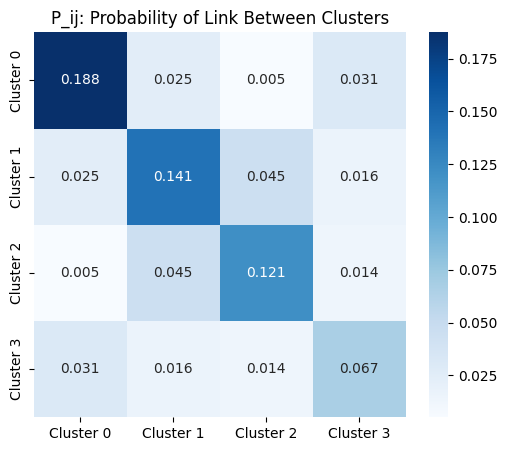

X shape: (97, 2)
First 5 rows of X:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [0. 1.]]
Unique cluster labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3)}


In [ ]:
# 3) Define C(u,v) using P matrix
def C_score(u, v):
    cu = cluster_map.get(int(u))
    cv = cluster_map.get(int(v))
    if cu is None or cv is None:
        return 0.0
    return P[cu, cv]

from collections import Counter
print("Cluster sizes:", Counter(cluster_map.values()))

import pandas as pd

P_df = pd.DataFrame(P,
                    index=[f"Cluster {i}" for i in range(k)],
                    columns=[f"Cluster {j}" for j in range(k)])

print("\nCluster–Pair Probability Matrix (P_ij):")
print(P_df.round(4))

import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(6,5))
sns.heatmap(P_df, annot=True, cmap="Blues", fmt=".3f")
plt.title("P_ij: Probability of Link Between Clusters")
plt.show()
print("X shape:", X.shape)
print("First 5 rows of X:\n", X[:5])
print("Unique cluster labels:", set(clusters) if 'clusters' in globals() else "clusters not defined")


In [ ]:
# 4) Prepare train/test hidden-edge split for evaluation
# Make a copy graph to remove test edges
all_edges = list(G.edges())
train_edges, test_edges = train_test_split(all_edges, test_size=TEST_EDGE_FRAC, random_state=42)
G_train = G.copy()
G_train.remove_edges_from(test_edges)

# Build a set of candidate negative pairs (non-edges) for test
non_edges = []
nodes_list = list(G_train.nodes())
node_set = set(nodes_list)
# We'll sample negatives until we have NEG_POS_RATIO * len(test_edges)
needed_neg = int(len(test_edges) * NEG_POS_RATIO)
while len(non_edges) < needed_neg:
    u = random.choice(nodes_list)
    v = random.choice(nodes_list)
    if u == v:
        continue
    a, b = (u, v) if u < v else (v, u)
    if not G_train.has_edge(a, b):
        non_edges.append((a, b))

# Build test sample: positives = test_edges, negatives = sampled non_edges
test_pos = [(u, v) for u, v in test_edges]
test_neg = non_edges[:needed_neg]


In [ ]:
# 5) Compute structural score S(u,v) using Jaccard on G_train
# NetworkX jaccard_coefficient yields (u,v,score) for non-edges in G_train
jaccard_preds = { (u,v): p for u,v,p in jaccard_coefficient(G_train) }

def S_score(u, v):
    key = (u, v) if (u, v) in jaccard_preds else ((v, u) if (v, u) in jaccard_preds else None)
    return jaccard_preds.get(key, 0.0)

In [ ]:
def C_score(u, v):
    cu = cluster_map.get(int(u))
    cv = cluster_map.get(int(v))
    if cu is None or cv is None:
        return 0.0
    return P[cu, cv]

In [ ]:
pairs = []
labels = []
S_list = []
C_list = []

for (u, v) in test_pos:
    S_list.append(S_score(u, v))
    C_list.append(C_score(u, v))
    labels.append(1)

for (u, v) in test_neg:
    S_list.append(S_score(u, v))
    C_list.append(C_score(u, v))
    labels.append(0)

S_arr = np.array(S_list, dtype=float)
C_arr = np.array(C_list, dtype=float)
labels_arr = np.array(labels, dtype=int)

# Normalize S and C to [0,1] based on the test set ranges (safe simple approach)
scaler = MinMaxScaler()
SC_combined = np.vstack([S_arr, C_arr]).T
SC_norm = scaler.fit_transform(SC_combined)
S_norm = SC_norm[:,0]
C_norm = SC_norm[:,1]

In [ ]:

# 7) Compute assortativity r for attributes used (gender+branch)
# Here we compute assortativity for 'gender' and 'branch' separately and average them (simple)
r_vals = []
for attr in ["gender", "branch"]:
    if attr in nodes_df.columns:
        try:
            r_vals.append(nx.attribute_assortativity_coefficient(G, attr))
        except Exception:
            # if attribute numeric or otherwise not applicable, skip
            pass
if len(r_vals) == 0:
    r = 0.0
else:
    r = np.mean(r_vals) #avg

# Map r to attribute weight w_attr in [0,1], and structure weight x = 1 - w_attr
w_attr = (r + 1.0) / 2.0
x_assort = 1.0 - w_attr
print(f"Assortativity r (avg of used attrs) = {r:.3f}, w_attr={w_attr:.3f}, x_assort={x_assort:.3f}")

# 8) Combine and evaluate: compute Final = x*S + (1-x)*C for various x, find best AUC
def final_scores_for_x(x_val, Svals, Cvals):
    return x_val * Svals + (1.0 - x_val) * Cvals

# grid search for x
xs = np.linspace(0,1,21)  # step 0.05
best_auc = -1  #To find the best x that gives the highest AUC score.
best_x = None
auc_list = []
for xv in xs:
    final_scores = final_scores_for_x(xv, S_norm, C_norm)
    try:
        auc = roc_auc_score(labels_arr, final_scores)  # Higher AUC = better link prediction.
    except ValueError:
        auc = 0.0
    auc_list.append((xv, auc))
    if auc > best_auc:
        best_auc = auc
        best_x = xv

print("Grid search results (x, AUC):")
for xv, auc in auc_list:
    print(f"{xv:.2f} -> {auc:.4f}")
print(f"Best x by AUC = {best_x:.2f} with AUC = {best_auc:.4f}")
print(f"Assortativity-derived x = {x_assort:.2f}")

# 9) AUC for assortativity-derived x
final_assort_scores = final_scores_for_x(x_assort, S_norm, C_norm)
auc_assort = roc_auc_score(labels_arr, final_assort_scores)
print(f"AUC for assortativity-derived x ({x_assort:.2f}): {auc_assort:.4f}")

# 10) Precision@k for the chosen x (best_x and assortativity x)
def precision_at_k(scores, labels, k):
    idx = np.argsort(scores)[::-1]  # descending
    topk = idx[:k]
    return labels[topk].sum() / float(k)

k = min(PRECISION_K, len(labels_arr))
prec_best = precision_at_k(final_scores_for_x(best_x, S_norm, C_norm), labels_arr, k)
prec_assort = precision_at_k(final_assort_scores, labels_arr, k)
print(f"Precision@{k} best_x={best_x:.2f}: {prec_best:.4f}")
print(f"Precision@{k} assort_x={x_assort:.2f}: {prec_assort:.4f}")

# 11) Save cluster labels back to nodes_df and G already set; print small summary
nodes_df["cluster"] = nodes_df["id"].map(cluster_map)
print("Cluster counts:", nodes_df['cluster'].value_counts().to_dict())


Assortativity r (avg of used attrs) = 0.000, w_attr=0.500, x_assort=0.500
Grid search results (x, AUC):
0.00 -> 0.6826
0.05 -> 0.7499
0.10 -> 0.7557
0.15 -> 0.7639
0.20 -> 0.7675
0.25 -> 0.7761
0.30 -> 0.7823
0.35 -> 0.7864
0.40 -> 0.7893
0.45 -> 0.7944
0.50 -> 0.7987
0.55 -> 0.8115
0.60 -> 0.8180
0.65 -> 0.8287
0.70 -> 0.8374
0.75 -> 0.8496
0.80 -> 0.8566
0.85 -> 0.8613
0.90 -> 0.8646
0.95 -> 0.8603
1.00 -> 0.8381
Best x by AUC = 0.90 with AUC = 0.8646
Assortativity-derived x = 0.50
AUC for assortativity-derived x (0.50): 0.7987
Precision@50 best_x=0.90: 0.9200
Precision@50 assort_x=0.50: 0.8000
Cluster counts: {1: 47, 0: 32, 2: 12, 3: 6}


In [1]:
x_final = best_x   # or x_assort
print("Using x =", x_final)

NameError: name 'best_x' is not defined

In [ ]:
# Structural-only AUC (x = 1)
auc_struct_only = roc_auc_score(labels_arr, S_norm)
print("Structural-only AUC (x=1):", auc_struct_only)

# Attribute-only AUC (x = 0)
auc_attr_only = roc_auc_score(labels_arr, C_norm)
print("Attribute-only AUC (x=0):", auc_attr_only)

# Hybrid AUC (x = best_x)
final_hybrid_scores = final_scores_for_x(best_x, S_norm, C_norm)
auc_hybrid = roc_auc_score(labels_arr, final_hybrid_scores)
print("Hybrid AUC (x=best_x):", auc_hybrid, "   best_x =", best_x)


Structural-only AUC (x=1): 0.8381171921475312
Attribute-only AUC (x=0): 0.6825550267697799
Hybrid AUC (x=best_x): 0.864589530041642    best_x = 0.9


In [ ]:
def recommend_for_node(G, node, x):
    neighbors = set(G.neighbors(node))
    all_nodes = set(G.nodes())

    # non-neighbors (potential friends)
    candidates = all_nodes - neighbors - {node}

    scores = []
    for v in candidates:
        S = S_score(node, v)
        C = C_score(node, v)
        F = x * S + (1 - x) * C
        scores.append((v, S, C, F))

    # sort by final hybrid score
    scores = sorted(scores, key=lambda x: x[3], reverse=True)
    return scores



In [ ]:
topk = 10
recs = recommend_for_node(G, 12, x_final)[:topk]

print(f"\nTop {topk} predicted friends for node 12:")
for v, S, C, F in recs:
    print(f"Node {v}: Final={F:.4f}, S={S:.4f}, C={C:.4f}")


Top 10 predicted friends for node 12:
Node 18: Final=0.1974, S=0.2143, C=0.0452
Node 107: Final=0.1941, S=0.2000, C=0.1406
Node 109: Final=0.1941, S=0.2000, C=0.1406
Node 19: Final=0.1525, S=0.1538, C=0.1406
Node 25: Final=0.1426, S=0.1429, C=0.1406
Node 8: Final=0.1341, S=0.1333, C=0.1406
Node 39: Final=0.1199, S=0.1176, C=0.1406
Node 46: Final=0.1199, S=0.1176, C=0.1406
Node 7: Final=0.1141, S=0.1111, C=0.1406
Node 80: Final=0.1084, S=0.1176, C=0.0249


In [ ]:
def recommend_for_all_nodes(G, x, k=5):
    all_recs = {}
    for node in G.nodes():
        recs = recommend_for_node(G, node, x)[:k]
        all_recs[node] = recs
    return all_recs

all_predictions = recommend_for_all_nodes(G, x_final, k=5)

In [ ]:
for node, recs in all_predictions.items():
    print(f"\nNode {node} recommendations:")
    for v, S, C, F in recs:
        print(f"  {v}: Final={F:.3f}  S={S:.3f} C={C:.3f}")


Node 1 recommendations:
  107: Final=0.214  S=0.222 C=0.141
  48: Final=0.194  S=0.200 C=0.141
  14: Final=0.164  S=0.167 C=0.141
  19: Final=0.164  S=0.167 C=0.141
  5: Final=0.152  S=0.167 C=0.025

Node 90 recommendations:
  48: Final=0.152  S=0.167 C=0.016
  41: Final=0.130  S=0.143 C=0.016
  19: Final=0.114  S=0.125 C=0.016
  27: Final=0.103  S=0.111 C=0.031
  28: Final=0.093  S=0.100 C=0.031

Node 46 recommendations:
  109: Final=0.239  S=0.250 C=0.141
  45: Final=0.194  S=0.200 C=0.141
  22: Final=0.183  S=0.188 C=0.141
  23: Final=0.183  S=0.188 C=0.141
  3: Final=0.164  S=0.167 C=0.141

Node 8 recommendations:
  41: Final=0.239  S=0.250 C=0.141
  3: Final=0.194  S=0.200 C=0.141
  107: Final=0.178  S=0.182 C=0.141
  109: Final=0.178  S=0.182 C=0.141
  45: Final=0.143  S=0.143 C=0.141

Node 25 recommendations:
  86: Final=0.166  S=0.182 C=0.025
  14: Final=0.158  S=0.160 C=0.141
  12: Final=0.143  S=0.143 C=0.141
  8: Final=0.134  S=0.133 C=0.141
  83: Final=0.127  S=0.125 C=0.1

In [ ]:
def plot_recommendations(G, node, recs, k=5):
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(9, 7))

    # Base graph
    nx.draw_networkx_edges(G, pos, alpha=0.2)
    nx.draw_networkx_nodes(G, pos, node_color="lightgray", node_size=80)

    # Highlight target node
    nx.draw_networkx_nodes(G, pos, nodelist=[node],
                           node_color="blue", node_size=150, label="Target Node")

    # Top-k recommended friends
    top_nodes = [v for (v, *_ ) in recs[:k]]
    nx.draw_networkx_nodes(G, pos, nodelist=top_nodes,
                           node_color="green", node_size=120, label="Recommendations")

    # Draw predicted edges
    pred_edges = [(node, v) for v in top_nodes]
    nx.draw_networkx_edges(G, pos, edgelist=pred_edges,
                           edge_color="red", style="dashed", width=2, label="Predicted Links")

    plt.title(f"Top {k} Recommended Friends for Node {node}")
    plt.axis("off")
    plt.legend()
    plt.show()


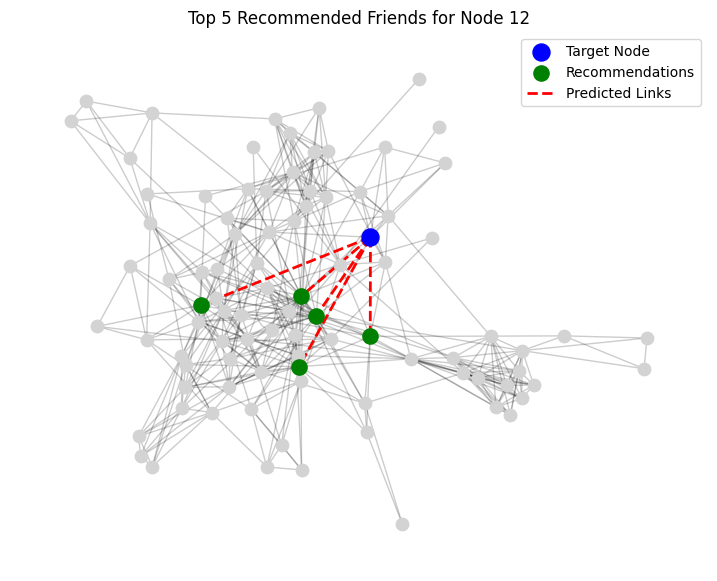

In [ ]:
#recs = recommend_for_node(G, 12, x_final) - not important
plot_recommendations(G, 12, recs, k=5)